# ED408 — Statistical Machine Learning II Lab
## Experiment 2: Decision Tree classifier (scikit-learn) with pruning and visualisation
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 2 — Decision Tree (scikit-learn) with pruning + visualisation

A fully grown tree memorises tens of thousands of pixels; we use **cost-complexity pruning** (`ccp_alpha`) chosen on a validation split, then visualise the pruned tree.

best ccp_alpha=1.76e-04, leaves=127, depth=13
test acc=0.7627, test F1=0.6182


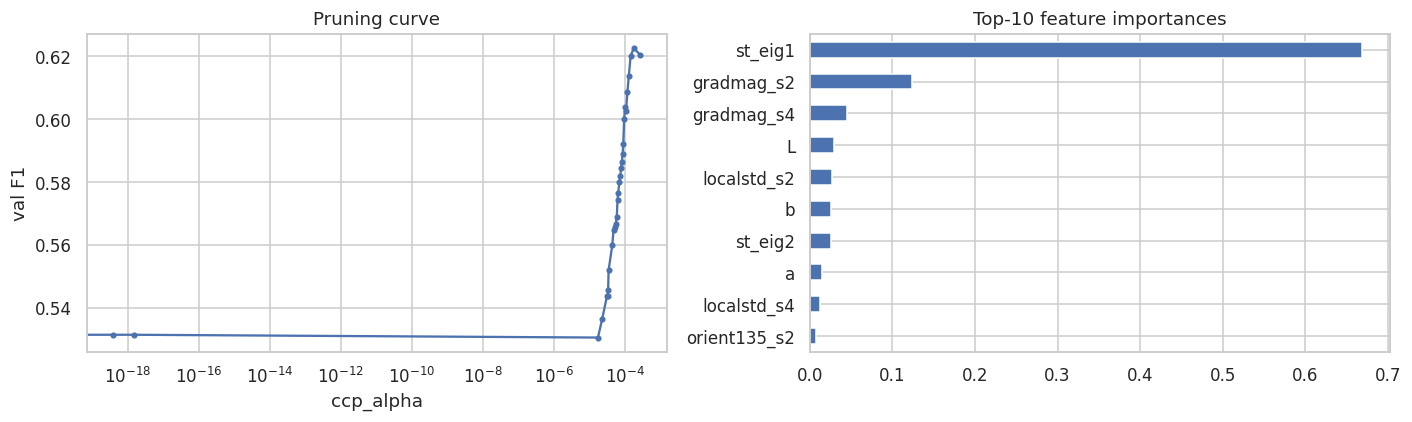

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split as tts

X_fit, X_val, y_fit, y_val = tts(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=0)

path = DecisionTreeClassifier(random_state=0, class_weight="balanced").cost_complexity_pruning_path(X_fit, y_fit)
alphas = np.unique(np.clip(path.ccp_alphas, 0, None))[::max(1, len(path.ccp_alphas)//40)]

val_f1 = []
for a in alphas:
    t = DecisionTreeClassifier(random_state=0, class_weight="balanced", ccp_alpha=a).fit(X_fit, y_fit)
    val_f1.append(f1_score(y_val, t.predict(X_val)))

best_a = alphas[int(np.argmax(val_f1))]
tree = DecisionTreeClassifier(random_state=0, class_weight="balanced", ccp_alpha=best_a).fit(X_tr, y_tr)
print(f"best ccp_alpha={best_a:.2e}, leaves={tree.get_n_leaves()}, depth={tree.get_depth()}")
print(f"test acc={accuracy_score(y_te, tree.predict(X_te)):.4f}, test F1={f1_score(y_te, tree.predict(X_te)):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(alphas, val_f1, ".-"); ax[0].set(xscale="log", xlabel="ccp_alpha", ylabel="val F1", title="Pruning curve")
imp = pd.Series(tree.feature_importances_, index=features).nlargest(10)
imp.plot.barh(ax=ax[1], title="Top-10 feature importances"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

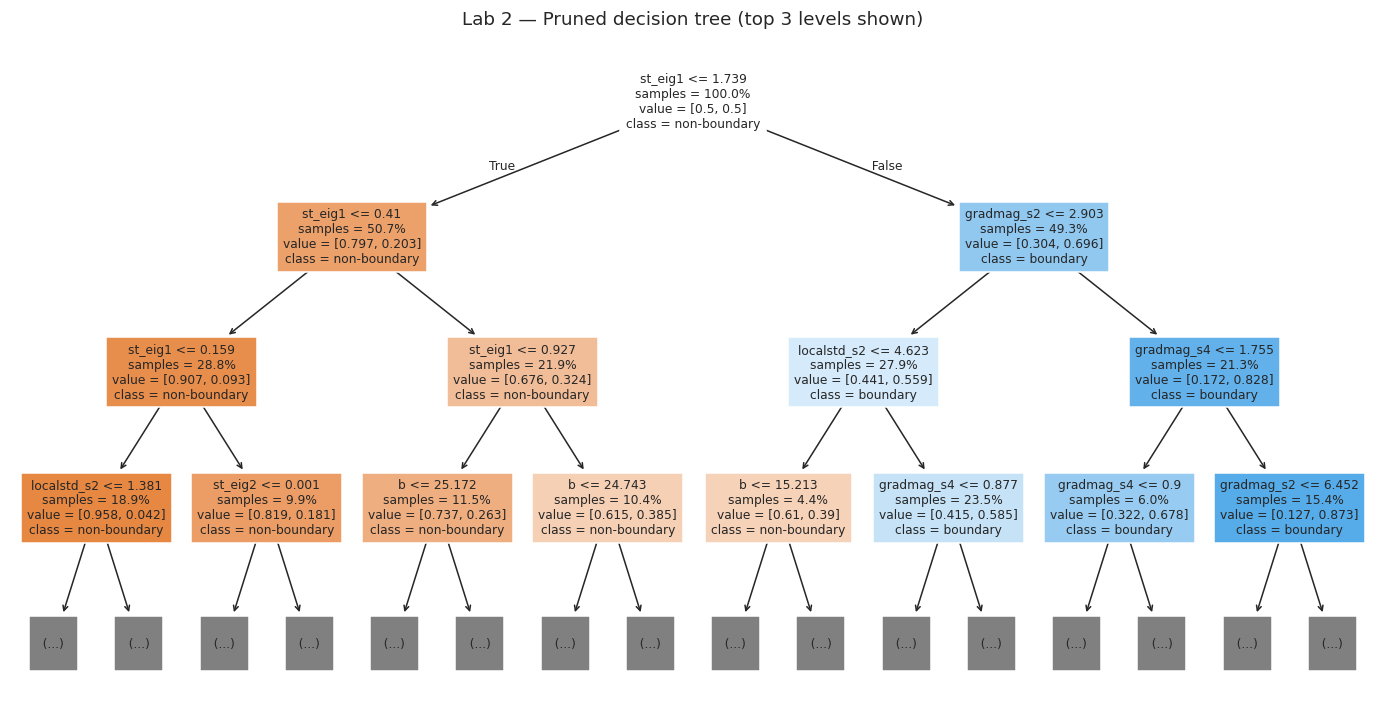

In [3]:
fig = plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=features, class_names=["non-boundary","boundary"],
          filled=True, max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title("Lab 2 — Pruned decision tree (top 3 levels shown)")
plt.show()

**Observations.** The tree's early splits use gradient/contrast features — a decision-tree rediscovery of classical edge detection: threshold the gradient. The interesting part is what pruning removes: deep leaves that memorised individual textured regions (grass, water) where filters fire strongly but humans draw no boundary.